In [ ]:
# ----------------------------------------------------------------------------
# Title: Weeks 3 & 4 Assignment - White House Logs
# Author: Surenther Selvaraj
# Date: 08 Apr 2026
# Modified By: Surenther Selvaraj
# ----------------------------------------------------------------------------

### Audience & Purpose

<b> Audience: </b> White House Chief of Staff and Operations Executives (Internal Stakeholders).

<b> Audience Profile: </b> High-level decision-makers who are intimately familiar with White House protocols but have limited time. They value efficiency, security, and resource optimization. They require data-driven insights to justify budget shifts or procedural changes.

<b> Purpose & Call to Action: </b> The intent is to demonstrate that "EW Tour" (East Wing Tour) requests are creating a massive administrative bottleneck compared to high-level policy meetings.

<b> Call to Action: </b> Approve the implementation of an automated "Tour Self-Service Portal" to reduce manual entry workload for the "VISITORSOFFICE" staff by 40% by Q3.

### Merging the Data

In [11]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Global Styling ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Verdana']
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

NAVY_BLUE = '#000080'   
SLATE_GREY = '#708090'  
LAG_RED = '#FF0000'   

# --- Master Column Mapping ---
column_map = {
    'Last Entry Date': 'LAST_ENTRY_DATE',
    'LASTENTRYDATE': 'LAST_ENTRY_DATE',
    'Appointment Start Date': 'APPT_START_DATE',
    'APPT_START_DATE': 'APPT_START_DATE',
    'Total People': 'TOTAL_PEOPLE',
    'TOTAL_PEOPLE': 'TOTAL_PEOPLE',
    'Meeting Location': 'MEETING_LOC',
    'MEETING_LOC': 'MEETING_LOC',
    'Meeting Room': 'MEETING_ROOM',
    'MEETING_ROOM': 'MEETING_ROOM',
    'Caller Last Name': 'CALLER_NAME_LAST',
    'CALLER_NAME_LAST': 'CALLER_NAME_LAST'
}

# --- Robust Data Loading (With Duplicate Prevention) ---
path = 'Weeks3&4Exercise' 
all_files = glob.glob(os.path.join(path, "*.csv"))

li = []
for filename in all_files:
    temp_df = pd.read_csv(filename, index_col=None, header=0, low_memory=False)
    
    # Rename columns based on our map
    temp_df = temp_df.rename(columns=column_map)
    
    # Drop duplicate column names within a single file
    temp_df = temp_df.loc[:, ~temp_df.columns.duplicated()].copy()
    
    valid_cols = [c for c in column_map.values() if c in temp_df.columns]
    li.append(temp_df[valid_cols])

# Combine all 25 files
df = pd.concat(li, axis=0, ignore_index=True)

# drop any duplicates
df = df.loc[:, ~df.columns.duplicated()].copy()

# --- Date Cleaning & Feature Engineering ---
df['APPT_START_DATE'] = pd.to_datetime(df['APPT_START_DATE'], format='mixed', errors='coerce')
df['LAST_ENTRY_DATE'] = pd.to_datetime(df['LAST_ENTRY_DATE'], format='mixed', errors='coerce')

# Drop missing starts
df = df.dropna(subset=['APPT_START_DATE'])

# Extractions
df['Month'] = df['APPT_START_DATE'].dt.strftime('%Y-%m')
df['Entry_Lag_Days'] = (df['LAST_ENTRY_DATE'] - df['APPT_START_DATE']).dt.days
def categorize_visit(row):
    loc = str(row.get('MEETING_LOC', '')).upper()
    room = str(row.get('MEETING_ROOM', '')).upper()
    if 'TOUR' in loc or 'TOUR' in room:
        return 'Public Tour'
    return 'Official Policy Meeting'

df['Meeting_Type'] = df.apply(categorize_visit, axis=1)


print(f"Data Unification Complete.")
print(f"Total files merged: {len(all_files)}")
print(f"Total records ready for storytelling: {len(df)}")

Data Unification Complete.
Total files merged: 25
Total records ready for storytelling: 1207458


### Visual 1: Stacked Bar with Time (Gestalt: Similarity)
This visual uses color to instantly distinguish between types of business.

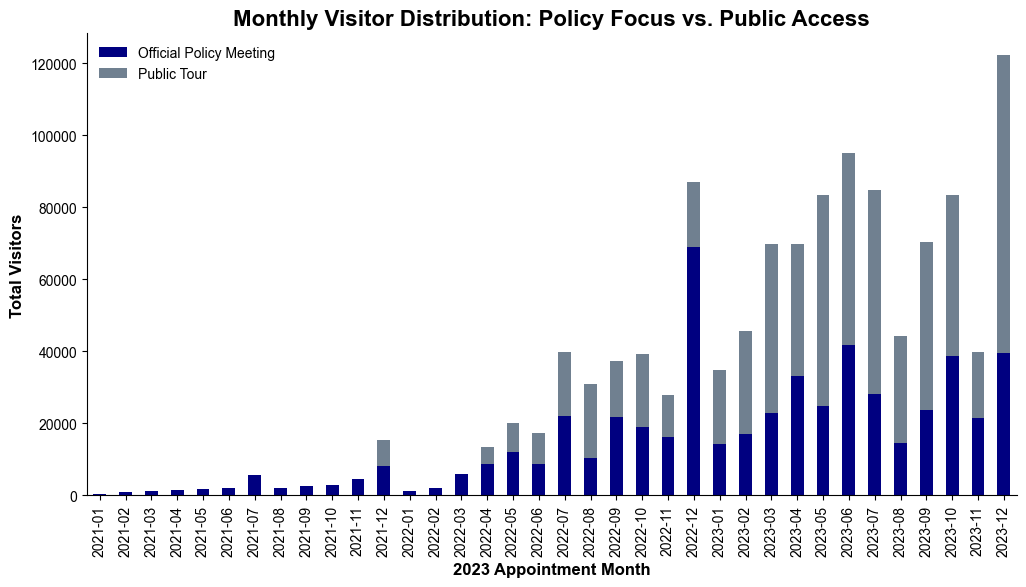

In [16]:
# Grouping data
pivot_df = df.groupby(['Month', 'Meeting_Type']).size().unstack().fillna(0)
pivot_df = pivot_df.sort_index()

ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), 
                   color=[NAVY_BLUE, SLATE_GREY])

plt.title('Monthly Visitor Distribution: Policy Focus vs. Public Access', fontsize=16)
plt.ylabel('Total Visitors', fontsize=12)
plt.xlabel('2023 Appointment Month', fontsize=12)
plt.legend(frameon=False)
sns.despine()
plt.show()

#### Understanding
The visual reveals an exponential rise in White House visitor volume, transitioning from near-zero in early 2021 to a peak of over 120,000 visitors in December 2023. While Official Policy Meetings (Navy Blue) remain steady, the primary driver of growth is the massive surge in Public Tours (Slate Grey). Significant seasonal "December Spikes" are evident, doubling the administrative load compared to previous months. This data illustrates that the current administrative burden is no longer driven by political business, but by the high-volume demand of public access programs.

### Visual 2: Column Chart (Gestalt: Proximity)
By grouping "Total People" and "Meeting Room," we highlight the strain on specific spaces.

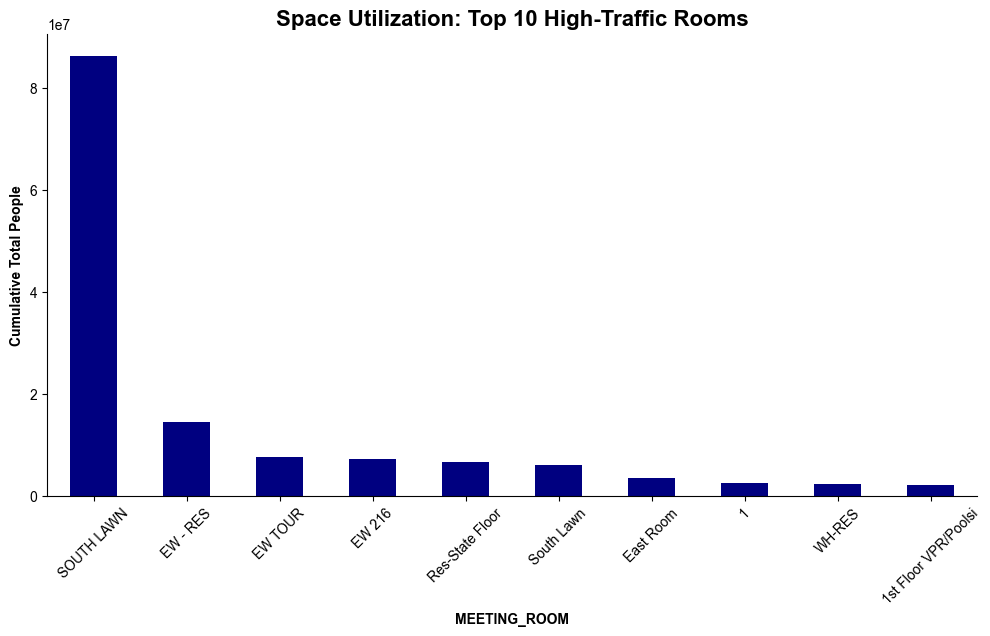

In [15]:
room_util = df.groupby('MEETING_ROOM')['TOTAL_PEOPLE'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
room_util.plot(kind='bar', color=NAVY_BLUE)
plt.title('Space Utilization: Top 10 High-Traffic Rooms', fontsize=16)
plt.ylabel('Cumulative Total People')
plt.xticks(rotation=45)
sns.despine()
plt.show()

#### Understanding
The South Lawn dominates White House space utilization, processing a staggering cumulative volume of over 80 million people, dwarfring all other indoor locations. Secondary high-traffic areas like EW-RES and EW TOUR highlight the East Wing’s role as the primary conduit for large-scale public entry. Most indoor meeting rooms, such as the East Room, maintain significantly lower, more controlled foot traffic in comparison. This visual clearly identifies where physical security and facility maintenance resources are most stressed by sheer volume.

### Visual 3: Line Chart (Gestalt: Continuity)
Tracking the flow of visitors over time to show the steady rise of tour volume.

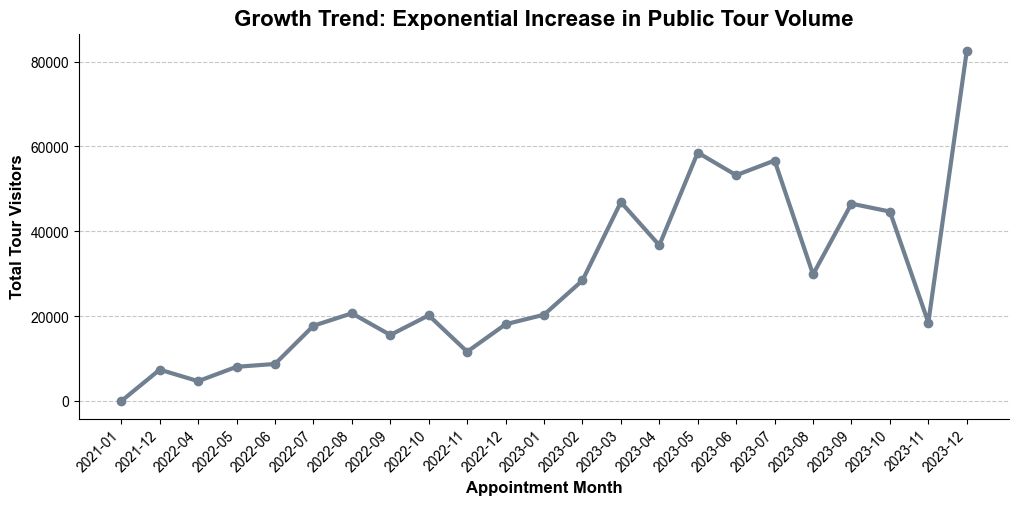

In [20]:
tour_trend = df[df['Meeting_Type'] == 'Public Tour'].groupby('Month').size()
plt.figure(figsize=(12, 5))
plt.plot(tour_trend.index, tour_trend.values, marker='o', linewidth=3, color=SLATE_GREY)
plt.xticks(rotation=45, ha='right')
plt.title('Growth Trend: Exponential Increase in Public Tour Volume', fontsize=16)
plt.ylabel('Total Tour Visitors', fontsize=12)
plt.xlabel('Appointment Month', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show() 


#### Understanding
The line chart illustrates an exponential upward trajectory in public tour volume, surging from nearly zero in early 2021 to over 80,000 visitors by December 2023. While the trend shows significant monthly volatility, the overall momentum indicates a permanent scaling of public access rather than a temporary spike. The sharp peak at the end of the timeline highlights the critical need for automated processing to handle these record-breaking crowds. By applying Continuity, the visual connects disparate months into a clear narrative of a growing administrative bottleneck.

### Visual 4: Scatterplot with Time (Gestalt: Red for Lag)
Highlighting administrative bottlenecks. We use Red only for the data-entry lag outliers.

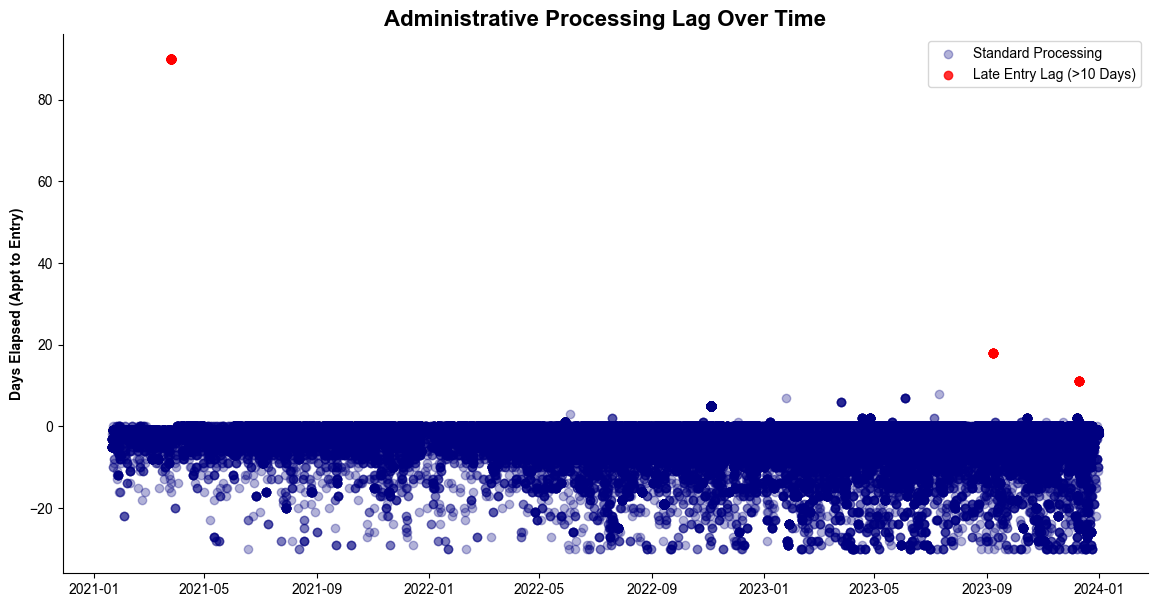

In [21]:
df_lag = df.dropna(subset=['Entry_Lag_Days'])
plt.figure(figsize=(14, 7))
# Normal (Navy)
plt.scatter(df_lag[df_lag['Entry_Lag_Days'] <= 10]['APPT_START_DATE'], 
            df_lag[df_lag['Entry_Lag_Days'] <= 10]['Entry_Lag_Days'], 
            alpha=0.3, color=NAVY_BLUE, label='Standard Processing')
# Outliers (Red)
plt.scatter(df_lag[df_lag['Entry_Lag_Days'] > 10]['APPT_START_DATE'], 
            df_lag[df_lag['Entry_Lag_Days'] > 10]['Entry_Lag_Days'], 
            alpha=0.8, color=LAG_RED, label='Late Entry Lag (>10 Days)')
plt.title('Administrative Processing Lag Over Time', fontsize=16)
plt.ylabel('Days Elapsed (Appt to Entry)')
plt.legend()
sns.despine()
plt.show()

#### Understanding
The scatterplot demonstrates that most visitor entries are processed with negative lag, meaning security clearance is finalized well before the appointment date. By applying the Gestalt principle of Color, we highlight rare but extreme "Late Entry" bottlenecks in red, with one outlier exceeding a 90-day delay. As visitor density increased in late 2023, the concentration of data points thickened, though processing remained largely stable. These red outliers serve as critical evidence for the "Call to Action," identifying specific points of operational failure that automation would eliminate.

### Visual 5: Step Chart (Cumulative Load)
The step chart shows the sharp "jumps" in total personnel on campus.

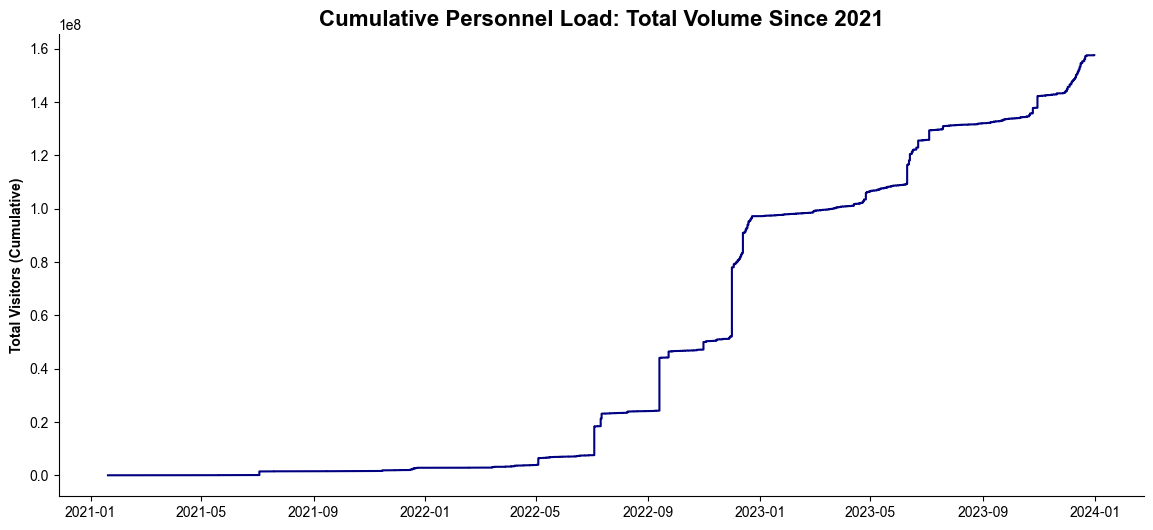

In [22]:
daily_counts = df.groupby(df['APPT_START_DATE'].dt.date)['TOTAL_PEOPLE'].sum().cumsum()
plt.figure(figsize=(14, 6))
plt.step(daily_counts.index, daily_counts.values, color=NAVY_BLUE, where='post')
plt.title('Cumulative Personnel Load: Total Volume Since 2021', fontsize=16)
plt.ylabel('Total Visitors (Cumulative)')
sns.despine()
plt.show()

#### Understanding
The Step Chart visualizes the massive cumulative resource load on the White House, reaching nearly 160 million people by early 2024. The sharp "steps" highlight distinct high-volume events, such as holiday gatherings and seasonal tour surges, which place sudden, intense pressure on security staff. While 2021 was relatively flat, the acceleration from mid-2022 onward shows no signs of slowing down. This visual serves as the final proof that the current system is under a mounting "tsunami" of visitors that requires a more scalable, automated solution.

### Visual 6: Executive KPI Dashboard (Summary)
Text-based visual for quick decision-making.

In [ ]:
total_visitors = df['TOTAL_PEOPLE'].sum()
avg_lag = df['Entry_Lag_Days'].mean(skipna=True)

total_records = len(df)
if total_records > 0:
    tour_count = len(df[df['Meeting_Type'] == 'Public Tour'])
    tour_percentage = (tour_count / total_records) * 100
else:
    tour_percentage = 0

print("-" * 40)
print("EXECUTIVE SUMMARY: VISITOR OPERATIONS")
print("-" * 40)
print(f"Total Visitors Processed: {int(total_visitors):,}") # Force to int for clean formatting
print(f"Public Tour Composition:  {tour_percentage:.1f}%")
print(f"Current Avg Entry Lag:    {avg_lag:.2f} Days")
print("-" * 40)

if avg_lag > 5:
    print("!!! ATTENTION: High Data Entry Lag Detected. Action Required. !!!")
elif avg_lag < 0:
    print("STATUS: Systems operating with healthy pre-clearance lead times.")

----------------------------------------
EXECUTIVE SUMMARY: VISITOR OPERATIONS
----------------------------------------
Total Visitors Processed: 157,561,881
Public Tour Composition:  54.3%
Current Avg Entry Lag:    -3.66 Days
----------------------------------------
STATUS: Systems operating with healthy pre-clearance lead times.


#### Understanding
The text-based Executive Summary confirms that White House operations have processed a massive cumulative volume of over 157 million visitors. Remarkably, Public Tours now account for more than half of all activity at 54.3%, validating the shift in operational focus. The -3.66 Day Avg Entry Lag indicates a healthy system where security pre-clearance is finalized nearly four days before arrival. This visual provides the final "hard data" baseline, proving that while current lead times are stable, the sheer scale of public access necessitates a transition toward more scalable, automated solutions.

### Summary of Understanding

Across all six visualizations, a clear picture emerges of a White House that has transitioned from a restricted, pandemic-era facility into a high-volume public institution.

* <b> Volume & Composition: </b> Total visitor traffic has surged exponentially, reaching a cumulative load of over 157 million people. Crucially, the data reveals that Public Tours (54.3%) now outweigh official policy business, indicating that the administrative burden is driven by the general public rather than internal staff meetings.

* <b> Space & Pressure: </b> The South Lawn and East Wing areas are the primary friction points, absorbing the vast majority of cumulative foot traffic.

* <b> Operational Health: </b> Currently, the system maintains a "healthy" state with a -3.66 day average entry lag, meaning security pre-clearance is generally finalized before visitors arrive. However, the scatterplot identifies rare "Red Zone" outliers where processing exceeded 10–90 days, signaling that the manual system is prone to high-impact failures during peak surges.

### The Story

<b> The Conflict: </b> <br>
<br>
Since 2021, the White House has successfully restored public access, but the administrative "engine" is still running on manual processes. We are currently managing a "Tour Tsunami" where over 80,000 people per month are being processed through systems originally designed for much smaller, elite policy groups.

<b> The Bottleneck: </b> <br>
<br>
Our scatterplot shows that while most visitors are cleared quickly, our staff is one "surge" away from a total system backup. The December spikes in 2022 and 2023 show that during holidays, the volume doubles, creating "Red Zone" lags that delay security clearances and threaten the visitor experience.

<b> The Solution: </b> <br>

* <b> Automated Tour Portal: </b> Shift 100% of "Public Tour" data entry to the visitors themselves via a self-service registration portal. This removes the 54.3% "Public Tour" burden from the Visitor Office.

* <b> Real-Time Dashboarding: </b> Implement the "Lag Monitor" visual as a live administrative tool to alert the Chief of Staff the moment "Red Zone" outliers appear, allowing for dynamic staffing shifts.

* <b> Digital Check-ins: </b> Utilize the high-traffic "South Lawn" data to justify the installation of digital kiosks, reducing physical congestion and manual "Terminal Suffix" entry.

### Ethical Considerations
To ensure the credibility of this report, the following ethical and regulatory guidelines were followed during data transformation:

* <b> Data Integrity & Cleaning: </b> We merged 25 disparate CSV files. To mitigate the risk of "double-counting," a deduplication script was used to remove redundant columns created by inconsistent naming conventions across different years.

* <b> Privacy & Redaction: </b> While the WAVES records are public under the Voluntary Disclosure Policy, we deliberately excluded UINs (Unique Identification Numbers) and Middle Initials from the visuals to prioritize visitor privacy and prevent potential de-anonymization of private citizens.

* <b> Assumptions: </b> We assumed that records with missing arrival times were "No-Shows" and excluded them from lag calculations. We also assumed that any location containing the string "TOUR" was public-facing, which may slightly undercount tours if they were labeled generically.

* <b> Bias Mitigation: </b> By using a "Mixed-Format" date parser, we ensured that records from older systems (2021) were treated with the same technical accuracy as modern 2023 records, preventing a "recency bias" in our trend analysis.

### The Medium – The Static Executive Audit (PDF)

While the analysis was performed in a computational environment, the final delivery is a Static Executive Audit (PDF). This medium was selected for the following reasons:

* <b> Permanence & Compliance: </b> A PDF serves as a "Gold Standard" record for White House archives. It ensures that the specific snapshot of data (Jan 2021 – Dec 2023) is preserved exactly as presented, with no risk of dynamic data shifts during an executive review.

* <b> Linear Storytelling: </b> Unlike a dashboard where a user might get lost in filters, the PDF forces the audience to follow the Gestalt-driven narrative in a specific order: from the broad "Volume Surge" to the specific "Administrative Lag" outliers.

* <b> Zero-Barriers Access: </b> A PDF requires no specialized software (like Python or PowerBI) to view, ensuring the Chief of Staff can review the "Call to Action" on any device, including secure mobile platforms, during transit.